In [ ]:
# # 📊 Sector-Level Market Stress Analysis

# This project analyzes sector-wise performance using ~2200 stocks.

# It evaluates:
# - Returns (5D, 15D, 30D)
# - Market Breadth
# - Dispersion (Risk)
# - Stress conditions

# Goal:
# 👉 Identify strong vs stressed sectors in the market.

In [3]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
#Importing data from duckdb
import pandas as pd
import duckdb

# Load Data
con = duckdb.connect("/home/jovyan/my_project/duckdb/turtle.duckdb")

df = con.execute("""
SELECT *
FROM sector_index
WHERE date = '2026-03-06'
""").df()

df.head()

,date,sector,ret_eq,ret_med,stock_count,pct_positive,dispersion_std,dispersion_iqr,index_value,ret_5d,index_chg_5d,breadth_chg_5d,dispersion_chg_5d,ret_15d,index_chg_15d,breadth_chg_15d,dispersion_chg_15d,ret_30d,index_chg_30d,breadth_chg_30d,dispersion_chg_30d
0,2026-03-06,Drug Manufacturers - Specialty & Generic,-0.002552,-0.004105,60,0.383333,0.013327,0.016191,91.218167,-0.030987,-0.030987,-0.100000,-0.003171,-0.038681,-0.038681,0.019697,-0.024303,0.007229,0.007229,-0.485519,-0.009181
1,2026-03-06,Apparel Manufacturing,-0.017280,-0.018451,16,0.250000,0.019626,0.026708,76.692651,-0.060186,-0.060186,-0.125000,0.005422,-0.145797,-0.145797,-0.035714,-0.011706,-0.070933,-0.070933,-0.500000,-0.008963
2,2026-03-06,Electrical Equipment & Parts,0.007167,0.000102,29,0.517241,0.022508,0.026709,94.196953,-0.020601,-0.020601,-0.344828,0.006537,0.004488,0.004488,0.169415,0.001601,0.120869,0.120869,-0.275862,0.001085
3,2026-03-06,Banks - Regional,-0.013083,-0.013318,37,0.108108,0.013024,0.012083,112.417657,-0.062320,-0.062320,-0.614114,-0.003328,-0.037133,-0.037133,-0.058559,0.001531,-0.023537,-0.023537,-0.756757,-0.007348
4,2026-03-06,Utilities - Independent Power Producers,0.001174,-0.003273,10,0.300000,0.018011,0.010813,77.472694,-0.041063,-0.041063,0.000000,0.003467,-0.088164,-0.088164,0.157143,0.002581,-0.062131,-0.062131,-0.700000,0.009798


In [5]:
#Key columns of the data

df[['sector', 'ret_5d', 'pct_positive', 'dispersion_std']].head()

,sector,ret_5d,pct_positive,dispersion_std
0,Drug Manufacturers - Specialty & Generic,-0.030987,0.383333,0.013327
1,Apparel Manufacturing,-0.060186,0.250000,0.019626
2,Electrical Equipment & Parts,-0.020601,0.517241,0.022508
3,Banks - Regional,-0.062320,0.108108,0.013024
4,Utilities - Independent Power Producers,-0.041063,0.300000,0.018011


In [6]:
#Sort for insights

df.sort_values('ret_5d', ascending=False)[['sector','ret_5d']].head(10)

,sector,ret_5d
65,Oil & Gas E&P,0.065492
96,Aluminum,0.057251
62,Oil & Gas Equipment & Services,0.050446
46,Leisure,0.041040
108,Aerospace & Defense,0.037956
80,Beverages - Brewers,0.036199
72,Medical Instruments & Supplies,0.032776
90,Confectioners,0.028500
111,Communication Equipment,0.023417
61,Oil & Gas Integrated,0.009761


In [ ]:
# ## 📌 Data Description

# Each row represents a sector with:

# - ret_eq → equal weighted return  
# - pct_positive → % of positive stocks  
# - dispersion_std → volatility  
# - ret_5d / 15d / 30d → momentum  

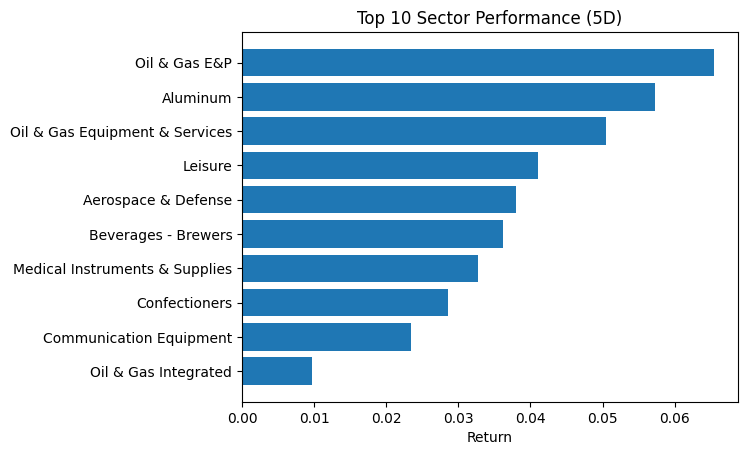

In [7]:
top = df.sort_values('ret_5d', ascending=False).head(10)

plt.figure()
plt.barh(top['sector'], top['ret_5d'])
plt.title("Top 10 Sector Performance (5D)")
plt.xlabel("Return")
plt.gca().invert_yaxis()
plt.show()

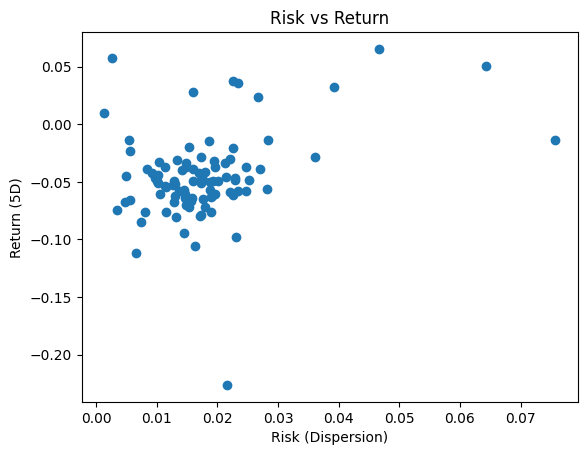

In [8]:
#Risk vs Return

plt.figure()
plt.scatter(df['dispersion_std'], df['ret_5d'])

plt.xlabel("Risk (Dispersion)")
plt.ylabel("Return (5D)")
plt.title("Risk vs Return")

plt.show()

In [9]:
#Stress Matrix

df['stress_flag'] = (
    (df['ret_5d'] < 0) &
    (df['pct_positive'] < 0.5) &
    (df['dispersion_std'] > df['dispersion_std'].mean())
)

df[df['stress_flag'] == True][['sector','ret_5d','pct_positive','dispersion_std']]

,sector,ret_5d,pct_positive,dispersion_std
1,Apparel Manufacturing,-0.060186,0.250000,0.019626
4,Utilities - Independent Power Producers,-0.041063,0.300000,0.018011
8,Farm & Heavy Construction Machinery,-0.098003,0.375000,0.023083
22,Engineering & Construction,-0.061055,0.360000,0.022583
25,Electronic Components,-0.047979,0.222222,0.022958
27,Drug Manufacturers - General,-0.046391,0.428571,0.022821
29,Textile Manufacturing,-0.058795,0.263158,0.022023
36,Medical Care Facilities,-0.031438,0.400000,0.019492
41,Luxury Goods,-0.076161,0.350000,0.018897
42,Real Estate - Development,-0.050417,0.241379,0.018830


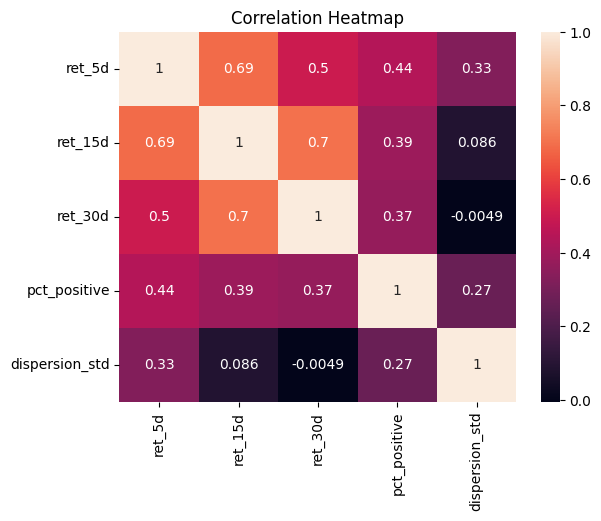

In [10]:
#Correlation Heatmap

corr = df[['ret_5d','ret_15d','ret_30d','pct_positive','dispersion_std']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()